# **PROYEK ANALISIS DATA**

**Menyiapkan semua library yang dibutuhkan**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode

# **DATA WRAGLING**

**Gathering Data**

In [102]:
raw_path = '/content/drive/MyDrive/Colab_Notebooks/dicoding/INTERMEDIATE/dataset/'
customers    = pd.read_csv(raw_path + 'customers_dataset.csv');
geolocation  = pd.read_csv(raw_path + 'geolocation_dataset.csv');
order_items  = pd.read_csv(raw_path + 'order_items_dataset.csv');
payments     = pd.read_csv(raw_path + 'order_payments_dataset.csv')
reviews      = pd.read_csv(raw_path + 'order_reviews_dataset.csv')
orders       = pd.read_csv(raw_path + 'orders_dataset.csv')
products     = pd.read_csv(raw_path + 'products_dataset.csv')
sellers      = pd.read_csv(raw_path + 'sellers_dataset.csv')
cat_tr       = pd.read_csv(raw_path + 'product_category_name_translation.csv')

In [103]:
datasets = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': cat_tr
}

for name, df in datasets.items():
    print(f"\n=== Sample {name} ===")
    print(df.head())
    print("\n==================================================================================")


=== Sample customers ===
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


=== Sample geolocation ===
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037

## **ASSESING DATA**

**Menilai Tabel**

In [104]:
# Tampilkan nama file dan shape masing-masing
for name, df in datasets.items():
    print(f"{name:20} : {df.shape}")

customers            : (99441, 5)
geolocation          : (1000163, 5)
order_items          : (112650, 7)
payments             : (103886, 5)
reviews              : (99224, 7)
orders               : (99441, 8)
products             : (32951, 9)
sellers              : (3095, 4)
category_translation : (71, 2)


In [105]:
# Info dasar semua tabel (tipe data & non-null count)
for name, df in datasets.items():
    print(f"\n=== {name.upper()} ===")
    df.info()
    print("\n==============================================================")


=== CUSTOMERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


=== GEOLOCATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geoloc

In [106]:
# Menampilkan Rangkuman dataset secara visual agar lebih mudah
info_data = []
for name, df in datasets.items():
    null_counts = df.isnull().sum()
    null_cols = [col for col, val in null_counts.items() if val > 0]

    info_data.append({
        'dataset': name,
        'n_rows': df.shape[0],
        'n_cols': df.shape[1],
        'null_amount': null_counts.sum(),
        'duplicate_amount': df.duplicated().sum(),
        'qty_null_columns': len(null_cols),
        'null_columns': ', '.join(null_cols)
    })

data_info = pd.DataFrame(info_data)
data_info.style.background_gradient()

,dataset,n_rows,n_cols,null_amount,duplicate_amount,qty_null_columns,null_columns
0,customers,99441,5,0,0,0,
1,geolocation,1000163,5,0,261831,0,
2,order_items,112650,7,0,0,0,
3,payments,103886,5,0,0,0,
4,reviews,99224,7,145903,0,2,"review_comment_title, review_comment_message"
5,orders,99441,8,4908,0,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
6,products,32951,9,2448,0,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,sellers,3095,4,0,0,0,
8,category_translation,71,2,0,0,0,


In [107]:
# Unique values di kolom penting
print("Unique customer_unique_id:", customers['customer_unique_id'].nunique())
print("Unique order_id:", orders['order_id'].nunique())
print("Unique status:", orders['order_status'].unique())
print("Unique product_id:", products['product_id'].nunique())
print("Unique seller_id:", sellers['seller_id'].nunique())
print("Kategori unik (PT):", products['product_category_name'].nunique())
print("Payment types:", payments['payment_type'].unique())
print("Review scores:", sorted(reviews['review_score'].unique()))

Unique customer_unique_id: 96096
Unique order_id: 99441
Unique status: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
Unique product_id: 32951
Unique seller_id: 3095
Kategori unik (PT): 73
Payment types: ['credit_card' 'boleto' 'voucher' 'debit_card' 'not_defined']
Review scores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


# **CLEANING DATA**


**Membersihkan Tabel `customers`**

Convert Tipe Data

In [108]:
# Ubah zip code prefix jadi string 5 digit
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str).str.zfill(5)

# Cek tipe data dan sample setelah ubah
print("Tipe data setelah cleaning:")
print(customers.dtypes)

print("\nSample customers setelah cleaning:")
print(customers.head())

Tipe data setelah cleaning:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix    object
customer_city               object
customer_state              object
dtype: object

Sample customers setelah cleaning:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

  customer_zip_code_prefix          customer_city customer_state  
0                    14409                 franca             SP  
1                    09790  sao bernardo do campo             SP  
2                    01151              sao paulo             SP  
3                    08775        mogi d

Cek Id Customer Order, Melihat Buyer Repeat Order

In [109]:
# Cek unique customer
print("\nJumlah unique customer_id:", customers['customer_id'].nunique())
print("Jumlah unique customer_unique_id (repeat buyer):", customers['customer_unique_id'].nunique())

print("Jumlah repeat buyer:", customers['customer_id'].nunique() - customers['customer_unique_id'].nunique())


Jumlah unique customer_id: 99441
Jumlah unique customer_unique_id (repeat buyer): 96096
Jumlah repeat buyer: 3345


**Membersihkan Tabel `geolocation`**

Convert Tipe Data

In [110]:
# Ubah zip code prefix jadi string 5 digit
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].astype(str).str.zfill(5)

# Cek tipe data & sample awal
print("Tipe data geolocation:")
print(geolocation.dtypes)
print("\nSample :")
print(geolocation.head())

Tipe data geolocation:
geolocation_zip_code_prefix     object
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

Sample :
  geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                       01037       -23.545621       -46.639292   
1                       01046       -23.546081       -46.644820   
2                       01046       -23.546129       -46.642951   
3                       01041       -23.544392       -46.639499   
4                       01035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


Handle Duplicate

In [111]:
# Group by zip prefix
# - mean untuk lat & lng
# - mode untuk city & state

geo_clean = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'geolocation_state': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
}).reset_index()

# Cek hasil
print("Jumlah rows setelah cleaning (unik per zip):")
print(geo_clean.info())
print("\nSample setelah cleaning:")
print(geo_clean.head())

Jumlah rows setelah cleaning (unik per zip):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  object 
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  object 
 4   geolocation_state            19015 non-null  object 
dtypes: float64(2), object(3)
memory usage: 742.9+ KB
None

Sample setelah cleaning:
  geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                       01001       -23.550190       -46.634024   
1                       01002       -23.548146       -46.634979   
2                       01003       -23.548994       -46.635731   
3                       01004       -23.549799       -46.634757   
4                    

**Membersihkan Tabel `order_item`**

Convert Tipe Data

In [112]:
# Convert shipping_limit_date ke datetime
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

# Cek tipe data setelah convert
print("Tipe data setelah convert:")
print(order_items.dtypes)

Tipe data setelah convert:
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


**Membersihkan Tabel `orders`**

Convert Tipe Data

In [113]:
# Convert semua kolom tanggal ke datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Cek tipe data setelah convert
print("Tipe data setelah convert:")
print(orders.dtypes)

Tipe data setelah convert:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


Handle Missing Value

In [114]:
# Filter hanya status 'delivered'
print("\nJumlah order sebelum filter:", len(orders))
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
print("Jumlah order setelah filter 'delivered':", len(orders_clean))

# Isi yang null: purchase_timestamp + 1 hari dari purchase time
# Kita gunakan fillna() hanya pada baris yang kosong
orders_clean['order_approved_at'] = orders_clean['order_approved_at'].fillna(
    orders_clean['order_purchase_timestamp'] + pd.to_timedelta(1, unit='D')
)

# Remove missing value sisanya
orders_clean = orders_clean.dropna(subset=[
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

# Cek lagi missing value-nya
print(orders_clean.isna().sum())


Jumlah order sebelum filter: 99441
Jumlah order setelah filter 'delivered': 96478
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


In [115]:
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96469 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96469 non-null  object        
 1   customer_id                    96469 non-null  object        
 2   order_status                   96469 non-null  object        
 3   order_purchase_timestamp       96469 non-null  datetime64[ns]
 4   order_approved_at              96469 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96469 non-null  datetime64[ns]
 6   order_delivered_customer_date  96469 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96469 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


**Membersihkan Tabel `reviews`**

Convert Tipe Data

In [116]:
# Convert tanggal ke datetime
date_cols_reviews = [
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols_reviews:
    reviews[col] = pd.to_datetime(reviews[col], errors='coerce')

# Cek tipe data setelah convert
print("Tipe data setelah convert:")
print(reviews.dtypes)

Tipe data setelah convert:
review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


Handle Missing Value

In [117]:
# Handle null di title & message
# Sebelum isi, buat kolom has_comment dulu berdasarkan kondisi asli
reviews['has_comment'] = reviews['review_comment_message'].notna().astype(int)

# Isi null dengan placeholder
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No title')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No comment')

# Cek hasil setelah handle
print("Missing values setelah handle:")
print(reviews[['review_comment_title', 'review_comment_message']].isna().sum())

print("\nSample setelah isi placeholder:")
print(reviews[['review_score', 'review_comment_title', 'review_comment_message', 'has_comment']].head())

reviews.info()

Missing values setelah handle:
review_comment_title      0
review_comment_message    0
dtype: int64

Sample setelah isi placeholder:
   review_score review_comment_title  \
0             4             No title   
1             5             No title   
2             5             No title   
3             5             No title   
4             5             No title   

                              review_comment_message  has_comment  
0                                         No comment            0  
1                                         No comment            0  
2                                         No comment            0  
3              Recebi bem antes do prazo estipulado.            1  
4  Parabéns lojas lannister adorei comprar pela I...            1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  ---

**Membersihkan Tabel `products`**

Handle Missing Value

In [118]:
# Periksa Missing Value Pada Product ID Apakah Ada Dalam Transaksi

# Ambil product_id yang null category_name
null_category_products = products[products['product_category_name'].isna()]['product_id']

print("Jumlah produk null category:", len(null_category_products))

# Ambil semua product_id unik dari order_items
ordered_products = order_items['product_id'].unique()

print("Jumlah produk unik yang pernah dibeli:", len(ordered_products))

# Cek intersection: berapa yang null category tapi pernah dibeli
null_but_ordered = null_category_products[null_category_products.isin(ordered_products)]

print("\nJumlah produk null category tapi pernah dibeli:", len(null_but_ordered))

# lihat detailnya
print("\nContoh 5 product_id null category tapi dibeli:")
print(null_but_ordered.head(5))

Jumlah produk null category: 610
Jumlah produk unik yang pernah dibeli: 32951

Jumlah produk null category tapi pernah dibeli: 610

Contoh 5 product_id null category tapi dibeli:
105    a41e356c76fab66334f36de622ecbd3a
128    d8dee61c2034d6d075997acef1870e9b
145    56139431d72cd51f19eb9f7dae4d1617
154    46b48281eb6d663ced748f324108c733
197    5fb61f482620cb672f5e586bb132eae9
Name: product_id, dtype: object


In [119]:
# Drop hanya null di dimensi/berat (hanya 2 baris)

products_clean = products.dropna(subset=[
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
])

print("Rows setelah drop dimensi null:", len(products_clean))



Rows setelah drop dimensi null: 32949


In [120]:
# Isi null category_name dengan placeholder
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('uncategorized')

# Isi null name_lenght, description_lenght, photos_qty dengan 0
cols_to_fill_zero = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty'
]
products_clean[cols_to_fill_zero] = products_clean[cols_to_fill_zero].fillna(0)

# Cek missing setelah cleaning
print("\nMissing setelah cleaning:")
print(products_clean.isna().sum())

print("\nJumlah produk 'uncategorized':", (products_clean['product_category_name'] == 'uncategorized').sum())

# Sample setelah cleaning
print("\nSample 5 baris dengan category 'uncategorized':")
print(products_clean[products_clean['product_category_name'] == 'uncategorized'].head())


Missing setelah cleaning:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Jumlah produk 'uncategorized': 609

Sample 5 baris dengan category 'uncategorized':
                           product_id product_category_name  \
105  a41e356c76fab66334f36de622ecbd3a         uncategorized   
128  d8dee61c2034d6d075997acef1870e9b         uncategorized   
145  56139431d72cd51f19eb9f7dae4d1617         uncategorized   
154  46b48281eb6d663ced748f324108c733         uncategorized   
197  5fb61f482620cb672f5e586bb132eae9         uncategorized   

     product_name_lenght  product_description_lenght  product_photos_qty  \
105                  0.0                         0.0                 0.0   
128                  0.0                         0.0    

/tmp/ipykernel_200/93260166.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  products_clean['product_category_name'] = products_clean['product_category_name'].fillna('uncategorized')
/tmp/ipykernel_200/93260166.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  products_clean[cols_to_fill_zero] = products_clean[cols_to_fill_zero].fillna(0)


**Membersihkan Tabel `sellers`**

Convert Tipe Data

In [121]:
# Ubah zip code prefix jadi string 5 digit
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str).str.zfill(5)

# Cek tipe data setelah ubah
print("Tipe data setelah cleaning:")
print(sellers.dtypes)

# Cek sample zip code
print("\nSample seller_zip_code_prefix setelah cleaning:")
print(sellers['seller_zip_code_prefix'].head())

Tipe data setelah cleaning:
seller_id                 object
seller_zip_code_prefix    object
seller_city               object
seller_state              object
dtype: object

Sample seller_zip_code_prefix setelah cleaning:
0    13023
1    13844
2    20031
3    04195
4    12914
Name: seller_zip_code_prefix, dtype: object


#**EDA ( EXPLORATORY DATA ANALYSIS )**

**Merge all data**

In [122]:
# Merge utama: mulai dari order_items
all_df = order_items.merge(
    orders_clean, on='order_id', how='left'
).merge(
    customers, on='customer_id', how='left'
).merge(
    payments, on='order_id', how='left'
).merge(
    reviews, on='order_id', how='left'
).merge(
    products_clean, on='product_id', how='left'
).merge(
    cat_tr, on='product_category_name', how='left'
).merge(
    sellers, on='seller_id', how='left'
)

# Buat kolom baru yang berguna
all_df['total_revenue'] = all_df['price'] + all_df['freight_value']
all_df['shipping_days'] = (all_df['order_delivered_customer_date'] -
                                 all_df['order_delivered_carrier_date']).dt.days
all_df['delay_days'] = (all_df['order_delivered_customer_date'] - all_df['order_estimated_delivery_date']).dt.days
all_df['purchase_month'] = all_df['order_purchase_timestamp'].dt.to_period('M')
all_df['has_comment'] = all_df['review_comment_message'].apply(lambda x: 1 if x != 'No comment' else 0)

print("Shape all_df setelah merge:", all_df.shape)
print(f'\n')

all_df.info()


Shape all_df setelah merge: (118310, 45)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118310 non-null  object        
 1   order_item_id                  118310 non-null  int64         
 2   product_id                     118310 non-null  object        
 3   seller_id                      118310 non-null  object        
 4   shipping_limit_date            118310 non-null  datetime64[ns]
 5   price                          118310 non-null  float64       
 6   freight_value                  118310 non-null  float64       
 7   customer_id                    115714 non-null  object        
 8   order_status                   115714 non-null  object        
 9   order_purchase_timestamp       115714 non-null  datetime64[ns]
 10  order_approved_at        

In [123]:
# Sample 5 baris acak
print("\nSample 5 baris acak:")
print(all_df.sample(5))


Sample 5 baris acak:
                               order_id  order_item_id  \
63410  895ab968e7bb0d5659d16cd74cd1650c              2   
26086  387016f36a926f6d861f812a8aeccffb              1   
94612  ccacf38d836bb451f51a555780ea425c              1   
40799  57ec43facf6675a86b249b5c44867350              1   
7654   1094dc9e3237f4deff27a2bab683a300              1   

                             product_id                         seller_id  \
63410  ebf9bc6cd600eadd681384e3116fda85  822166ed1e47908f7cfb49946d03c726   
26086  b623b7cb05ee3248fbe4a6ecbeed79a4  7aa4334be125fcdd2ba64b3180029f14   
94612  02dc711c164ca9c218d316491801ced9  77530e9772f57a62c906e1c21538ab82   
40799  36bd3e4daa4604d112f17dccd24ee59e  562fc2f2c2863ab7e79a9e4388a58a14   
7654   2bb3e85f2a403543fdb64e266e70c792  76d64c4aca3a7baf218bf93ef7fa768d   

      shipping_limit_date   price  freight_value  \
63410 2017-08-14 20:43:31   12.99          23.21   
26086 2017-12-13 17:32:17   70.97          17.75   
94612 2018

Cek missing setelah merge

In [124]:
print("\nMissing setelah merge:")
print(all_df.isna().sum()[all_df.isna().sum() > 0])


Missing setelah merge:
customer_id                      2596
order_status                     2596
order_purchase_timestamp         2596
order_approved_at                2596
order_delivered_carrier_date     2596
order_delivered_customer_date    2596
order_estimated_delivery_date    2596
customer_unique_id               2596
customer_zip_code_prefix         2596
customer_city                    2596
customer_state                   2596
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
review_id                         978
review_score                      978
review_comment_title              978
review_comment_message            978
review_creation_date              978
review_answer_timestamp           978
product_category_name              20
product_name_lenght                20
product_description_lenght         20
product_photos_qty                 20
product_weight_g          

Handing Missing Value

In [125]:
# Drop missing customer/orders
all_df_clean = all_df.dropna(subset=['customer_id', 'order_status', 'order_purchase_timestamp'])

# Isi review_score dengan median
median_score = all_df_clean['review_score'].median()
all_df_clean['review_score'] = all_df_clean['review_score'].fillna(median_score)

# Drop missing product kecil
all_df_clean = all_df_clean.dropna(subset=['product_category_name'])

# Drop missing payment kecil
all_df_clean = all_df_clean.dropna(subset=['payment_type'])

# Isi English category yang masih NaN
all_df_clean['product_category_name_english'] = all_df_clean['product_category_name_english'].fillna('Uncategorized')

# Final check
print("Shape akhir setelah handling missing:", all_df_clean.shape)
print("\nMissing tersisa (harusnya hampir 0):")
print(all_df_clean.isna().sum()[all_df_clean.isna().sum() > 0])


/tmp/ipykernel_200/249802507.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df_clean['review_score'] = all_df_clean['review_score'].fillna(median_score)


Shape akhir setelah handling missing: (115691, 45)

Missing tersisa (harusnya hampir 0):
review_id                  861
review_comment_title       861
review_comment_message     861
review_creation_date       861
review_answer_timestamp    861
dtype: int64


In [139]:
# Isi kolom review-related yang null dengan placeholder
all_df_clean['review_id'] = all_df_clean['review_id'].fillna('No review')
all_df_clean['review_comment_title'] = all_df_clean['review_comment_title'].fillna('No title')
all_df_clean['review_comment_message'] = all_df_clean['review_comment_message'].fillna('No comment')
all_df_clean['review_creation_date'] = all_df_clean['review_creation_date'].fillna(all_df_clean['order_delivered_customer_date'])
all_df_clean['review_answer_timestamp'] = all_df_clean['review_answer_timestamp'].fillna(all_df_clean['order_delivered_customer_date'])

# Final check ulang

print("\nShape akhir setelah handle review:", all_df_clean.shape)
print("\nMissing tersisa :")
print(all_df_clean.isna().sum()[all_df_clean.isna().sum() > 0])
print(f'\n')
all_df_clean.info()

# Simpan ke CSV
all_df_clean.to_csv("all_data_clean.csv", index=False)

print("Data berhasil disimpan ke all_data_clean.csv")


Shape akhir setelah handle review: (115691, 45)

Missing tersisa :
Series([], dtype: int64)


<class 'pandas.core.frame.DataFrame'>
Index: 115691 entries, 0 to 118309
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115691 non-null  object        
 1   order_item_id                  115691 non-null  int64         
 2   product_id                     115691 non-null  object        
 3   seller_id                      115691 non-null  object        
 4   shipping_limit_date            115691 non-null  datetime64[ns]
 5   price                          115691 non-null  float64       
 6   freight_value                  115691 non-null  float64       
 7   customer_id                    115691 non-null  object        
 8   order_status                   115691 non-null  object        
 9   order_purchase_timestamp       115691 non-null

Eksplorasi Persebaran Data


Persentase data yang di-filter (>60 hari): 0.25%


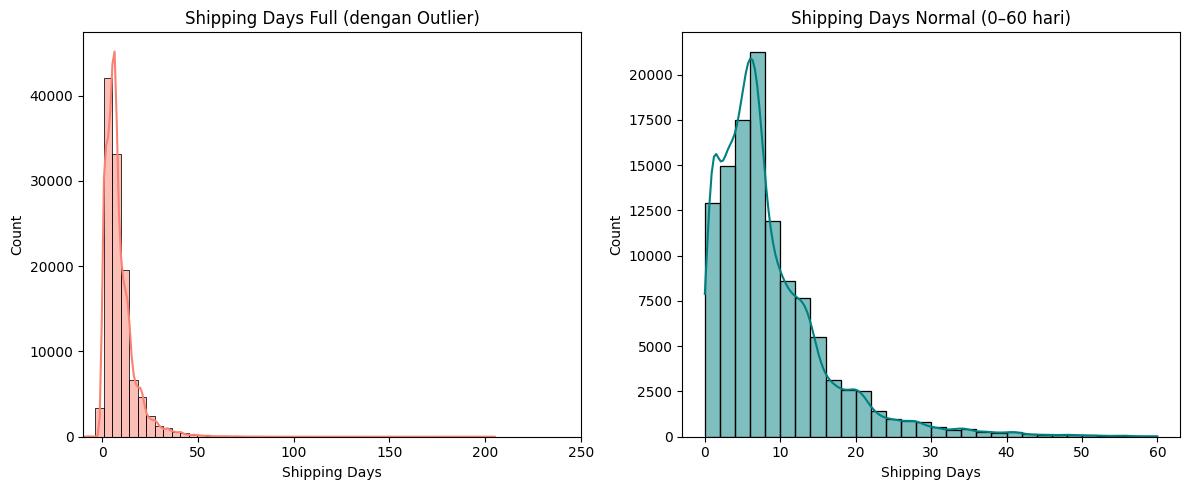

In [127]:
# Filter normal shipping 0–60 hari
all_df_clean_normal = all_df_clean[(all_df_clean['shipping_days'] >= 0) & (all_df_clean['shipping_days'] <= 60)]

print(f"\nPersentase data yang di-filter (>60 hari): {(len(all_df_clean) - len(all_df_clean_normal)) / len(all_df_clean) * 100:.2f}%")

# Histogram perbandingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(all_df_clean['shipping_days'], bins=50, kde=True, color='salmon')
plt.title('Shipping Days Full (dengan Outlier)')
plt.xlabel('Shipping Days')
plt.xlim(-10, 250)

plt.subplot(1, 2, 2)
sns.histplot(all_df_clean_normal['shipping_days'], bins=30, kde=True, color='teal')
plt.title('Shipping Days Normal (0–60 hari)')
plt.xlabel('Shipping Days')

plt.tight_layout()
plt.show()

In [128]:
# Persebaran order & revenue per state
state_summary = all_df_clean.groupby('customer_state').agg({
    'order_id': 'nunique',
    'total_revenue': 'sum'
}).reset_index()

state_summary = state_summary.sort_values('total_revenue', ascending=False)

print("Persebaran Order & Revenue per State:")
print(state_summary)


Persebaran Order & Revenue per State:
   customer_state  order_id  total_revenue
25             SP     40488     6074737.49
18             RJ     12349     2167478.25
10             MG     11351     1890459.10
22             RS      5342      906656.94
17             PR      4921      812530.81
4              BA      3256      627081.41
23             SC      3545      616255.25
6              DF      2079      360485.82
8              GO      1957      355374.39
7              ES      1995      328955.10
15             PE      1593      321062.12
5              CE      1279      281430.06
13             PA       946      219300.64
12             MT       885      185944.92
9              MA       717      151814.71
14             PB       517      148333.53
11             MS       701      139757.80
19             RN       474      113567.01
16             PI       475      111611.92
1              AL       397       97724.79
24             SE       335       72694.76
26             T

In [129]:
# Top 10 state by revenue
print("\nTop 10 State by Total Revenue:")
print(state_summary.head(10))


Top 10 State by Total Revenue:
   customer_state  order_id  total_revenue
25             SP     40488     6074737.49
18             RJ     12349     2167478.25
10             MG     11351     1890459.10
22             RS      5342      906656.94
17             PR      4921      812530.81
4              BA      3256      627081.41
23             SC      3545      616255.25
6              DF      2079      360485.82
8              GO      1957      355374.39
7              ES      1995      328955.10


In [130]:
# Persebaran item terjual & revenue per state per kategori
state_category = all_df_clean.groupby(['customer_state', 'product_category_name_english']).agg({
    'product_id': 'count',
    'total_revenue': 'sum'
}).reset_index()

state_category = state_category.rename(columns={'product_id': 'item_count'})

print("\nShape state per kategori:", state_category.shape)
print("\nSample 10 baris:")
print(state_category.head(10))


Shape state per kategori: (1377, 4)

Sample 10 baris:
  customer_state product_category_name_english  item_count  total_revenue
0             AC                 Uncategorized           2         127.34
1             AC                          auto           5         753.39
2             AC                          baby           3         871.97
3             AC                bed_bath_table           4         725.21
4             AC        books_general_interest           2         757.51
5             AC            christmas_supplies           1         130.85
6             AC                     computers           1        1251.70
7             AC         computers_accessories           8        1486.18
8             AC                consoles_games           1         321.92
9             AC                    cool_stuff           1         130.22


In [131]:
# Tampilkan top 5 kategori di top 5 state (by revenue)
top_states = state_summary['customer_state'].head(5).tolist()

print("\nTop 5 Kategori per State (by Revenue):")
for state in top_states:
    state_data = state_category[state_category['customer_state'] == state]
    top5 = state_data.sort_values('total_revenue', ascending=False).head(5)
    print(f"\n{state}:")
    print(top5[['product_category_name_english', 'item_count', 'total_revenue']])


Top 5 Kategori per State (by Revenue):

SP:
     product_category_name_english  item_count  total_revenue
1275                bed_bath_table        5576      586177.61
1311                 health_beauty        4265      525499.19
1337                 watches_gifts        2303      464640.30
1332                sports_leisure        3740      447967.33
1283         computers_accessories        3194      396957.32

RJ:
    product_category_name_english  item_count  total_revenue
927                bed_bath_table        1752      191419.40
988                 watches_gifts         858      191331.89
963                 health_beauty        1071      162857.36
983                sports_leisure        1067      152249.90
935         computers_accessories        1018      141787.88

MG:
    product_category_name_english  item_count  total_revenue
517                 health_beauty        1090      177858.89
483                bed_bath_table        1411      167742.39
543                 watc

# **Visualization & Explanatory Analysis**

**Bagaimana Performa Penjualan Dan Revenue Dari 2016 -2018?**

In [132]:
# Group by purchase_month
monthly_trend = all_df_clean.groupby('purchase_month').agg({
    'order_id': 'nunique',          # jumlah order unik per bulan
    'total_revenue': 'sum'          # total revenue (price + freight)
}).reset_index()

# Ubah purchase_month jadi string biar mudah plot
monthly_trend['purchase_month_str'] = monthly_trend['purchase_month'].astype(str)

print("\nTren bulanan (5 baris pertama & terakhir):")
print(monthly_trend.head())
print(monthly_trend.tail())

# Insight singkat
print("\nBulan dengan revenue tertinggi:",
      monthly_trend.loc[monthly_trend['total_revenue'].idxmax(), 'purchase_month_str'],
      f"→ R$ {monthly_trend['total_revenue'].max():,.0f}")

print("Bulan dengan order terbanyak:",
      monthly_trend.loc[monthly_trend['order_id'].idxmax(), 'purchase_month_str'],
      f"→ {monthly_trend['order_id'].max()} order")


Tren bulanan (5 baris pertama & terakhir):
  purchase_month  order_id  total_revenue purchase_month_str
0        2016-10       265       48314.12            2016-10
1        2016-12         1          19.62            2016-12
2        2017-01       749      136362.99            2017-01
3        2017-02      1653      286678.44            2017-02
4        2017-03      2543      441923.68            2017-03
   purchase_month  order_id  total_revenue purchase_month_str
17        2018-04      6798     1174143.49            2018-04
18        2018-05      6749     1171614.43            2018-05
19        2018-06      6096     1064467.35            2018-06
20        2018-07      6156     1066073.03            2018-07
21        2018-08      6351     1020340.91            2018-08

Bulan dengan revenue tertinggi: 2017-11 → R$ 1,204,899
Bulan dengan order terbanyak: 2017-11 → 7288 order


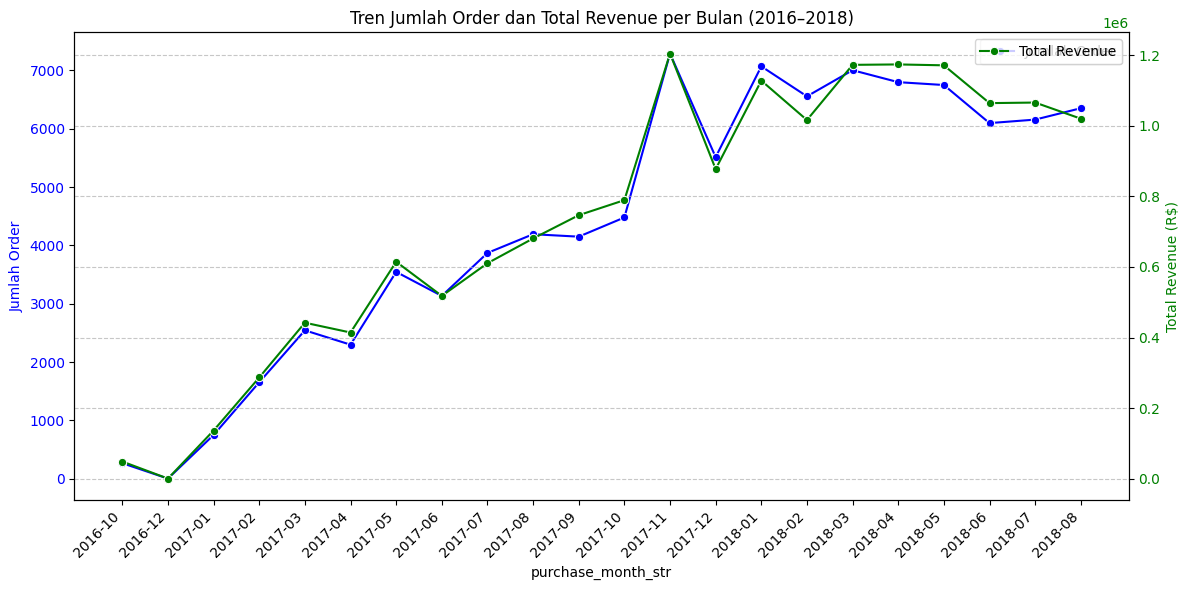

In [133]:
plt.figure(figsize=(12, 6))

# Line untuk jumlah order
ax1 = plt.gca()
sns.lineplot(data=monthly_trend, x='purchase_month_str', y='order_id',
             marker='o', color='blue', ax=ax1, label='Jumlah Order')
ax1.set_ylabel('Jumlah Order', color='blue')
ax1.set_xticks(range(len(monthly_trend)))
ax1.tick_params(axis='y', labelcolor='blue')

# Line untuk revenue
ax2 = ax1.twinx()
sns.lineplot(data=monthly_trend, x='purchase_month_str', y='total_revenue',
             marker='o', color='green', ax=ax2, label='Total Revenue')
ax2.set_ylabel('Total Revenue (R$)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax1.set_xticklabels(monthly_trend['purchase_month_str'], rotation=45, ha='right')

plt.title('Tren Jumlah Order dan Total Revenue per Bulan (2016–2018)')
plt.xlabel('Bulan')
# plt.xticks(rotation=50, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**


*   Terjadi tren pertumbuhan yang signifikan pada jumlah order dan total revenue dari tahun pertengahan 2017 hingga tahun 2018.
*   Terdapat lonjakan tajam pada November 2017, yang kemungkinan besar dipicu oleh event Black Friday.


*   Grafik menunjukkan korelasi yang sangat kuat antara jumlah order dan revenue; setiap kenaikan volume transaksi diikuti dengan kenaikan pendapatan yang proporsional, menandakan harga rata-rata produk yang terjual cenderung stabil setiap bulannya.






**Di Setiap Negara Bagian, Apa Kategori Produk Yang Paling Banyak Diminati ?**

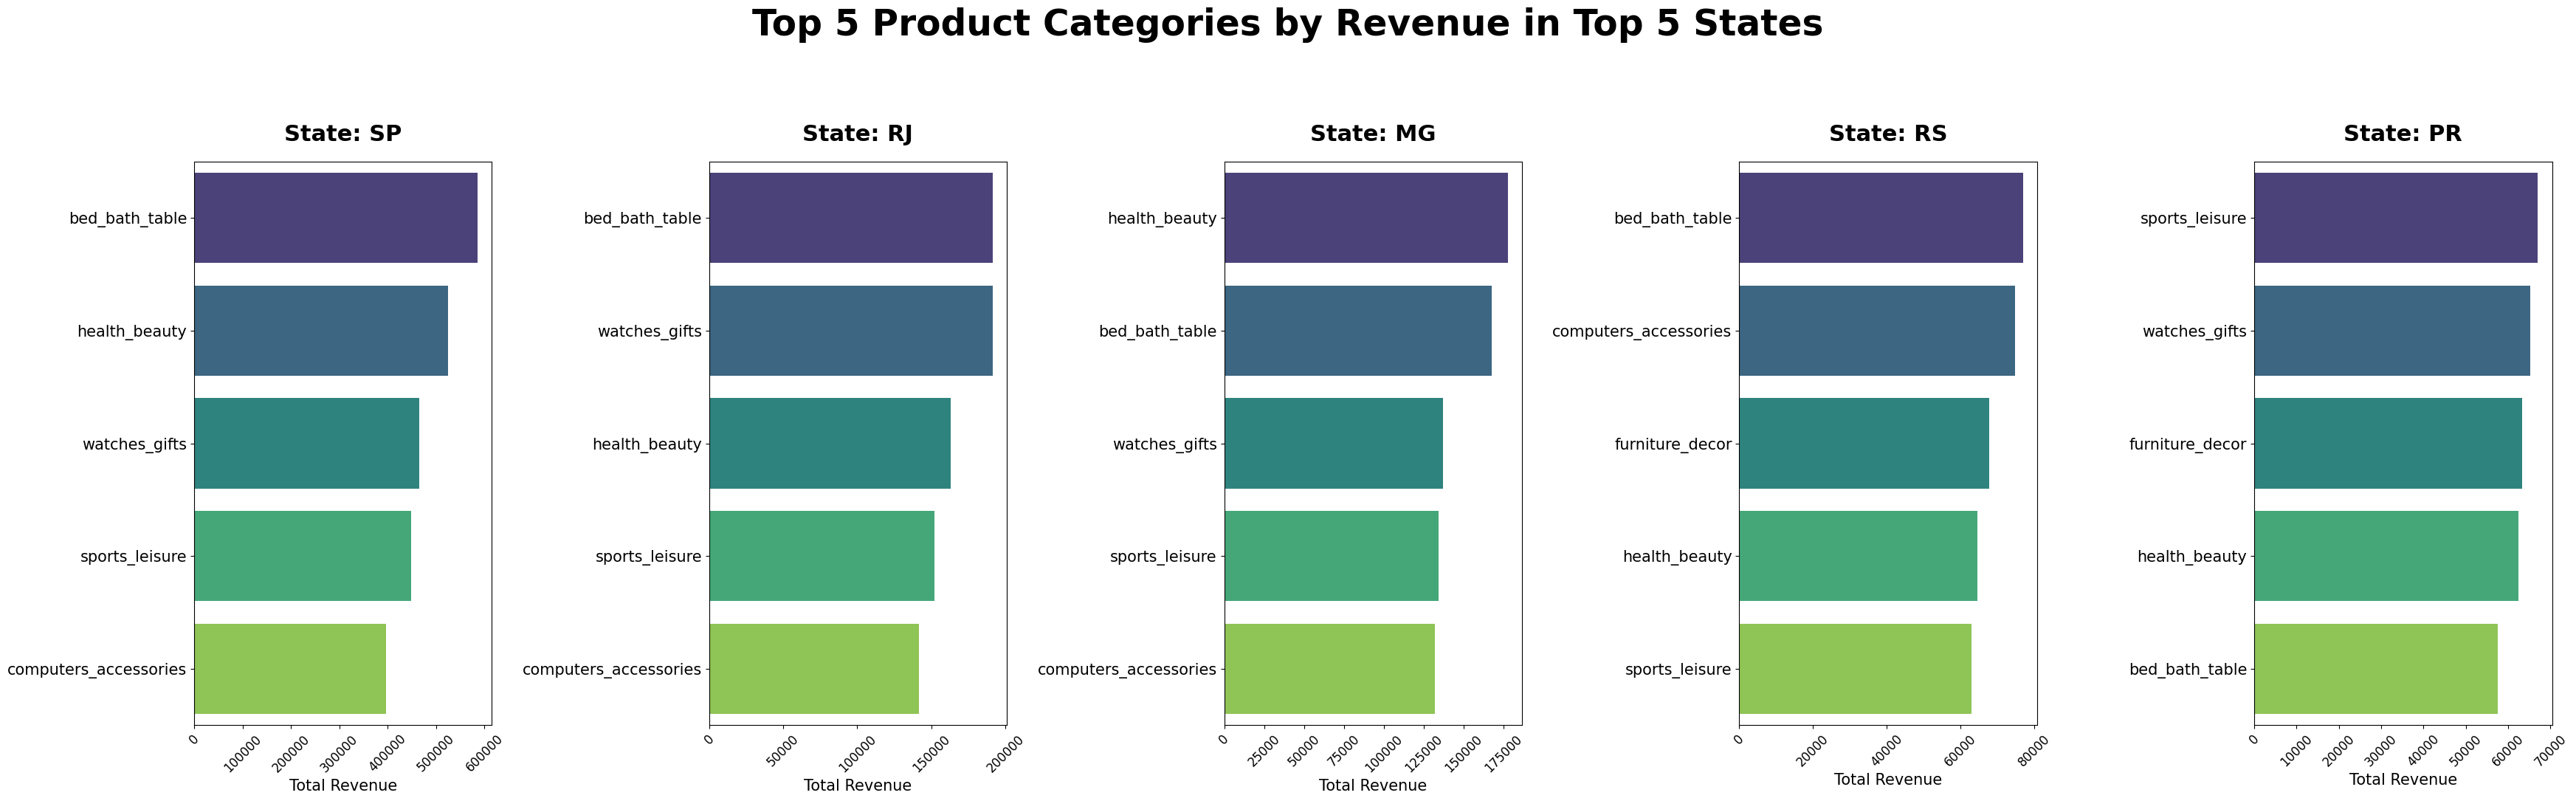

In [134]:
# Ambil list 5 state teratas
top_states = state_summary['customer_state'].head(5).tolist()

# Siapkan kanvas (1 baris, 5 kolom)
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(35, 10))

# Looping untuk membuat bar chart di tiap kolom
for i, state in enumerate(top_states):
    # Filter data per state
    state_data = state_category[state_category['customer_state'] == state]
    top_5_cat = state_data.sort_values('total_revenue', ascending=False).head(5)

    # Plot bar chart
    sns.barplot(
        x='total_revenue',
        y='product_category_name_english',
        data=top_5_cat,
        ax=ax[i],
        hue='product_category_name_english',
        palette='viridis',
        legend=False
    )

    # Kerapihan tiap subplot
    ax[i].set_title(f"State: {state}", fontsize=22, fontweight='bold', pad=20)
    ax[i].set_xlabel("Total Revenue", fontsize=15)
    ax[i].set_ylabel(None)
    ax[i].tick_params(axis='x', rotation=45, labelsize=12)
    ax[i].tick_params(axis='y', labelsize=15)

# Judul Utama & Layouting
plt.suptitle("Top 5 Product Categories by Revenue in Top 5 States", fontsize=35, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

**Insight:**


*   Analisis preferensi produk di tingkat wilayah menunjukkan konsistensi di mana kategori `bed_bath_table` selalu masuk dalam jajaran Top 5 di setiap negara bagian besar.
*   Negara bagian SP (São Paulo) memberikan kontribusi revenue tertinggi dengan kategori produk yang lebih variatif dibandingkan negara bagian lainnya.
*   Meskipun secara umum pola pembelian serupa, terdapat sedikit perbedaan pada kategori peringkat bawah di setiap state, yang mengindikasikan adanya variasi minat lokal atau pengaruh ketersediaan seller di wilayah tersebut.

**Apa Kategori Produk Yang Paling Banyak Diminati Dan Yang Paling Kurang Diminati?**

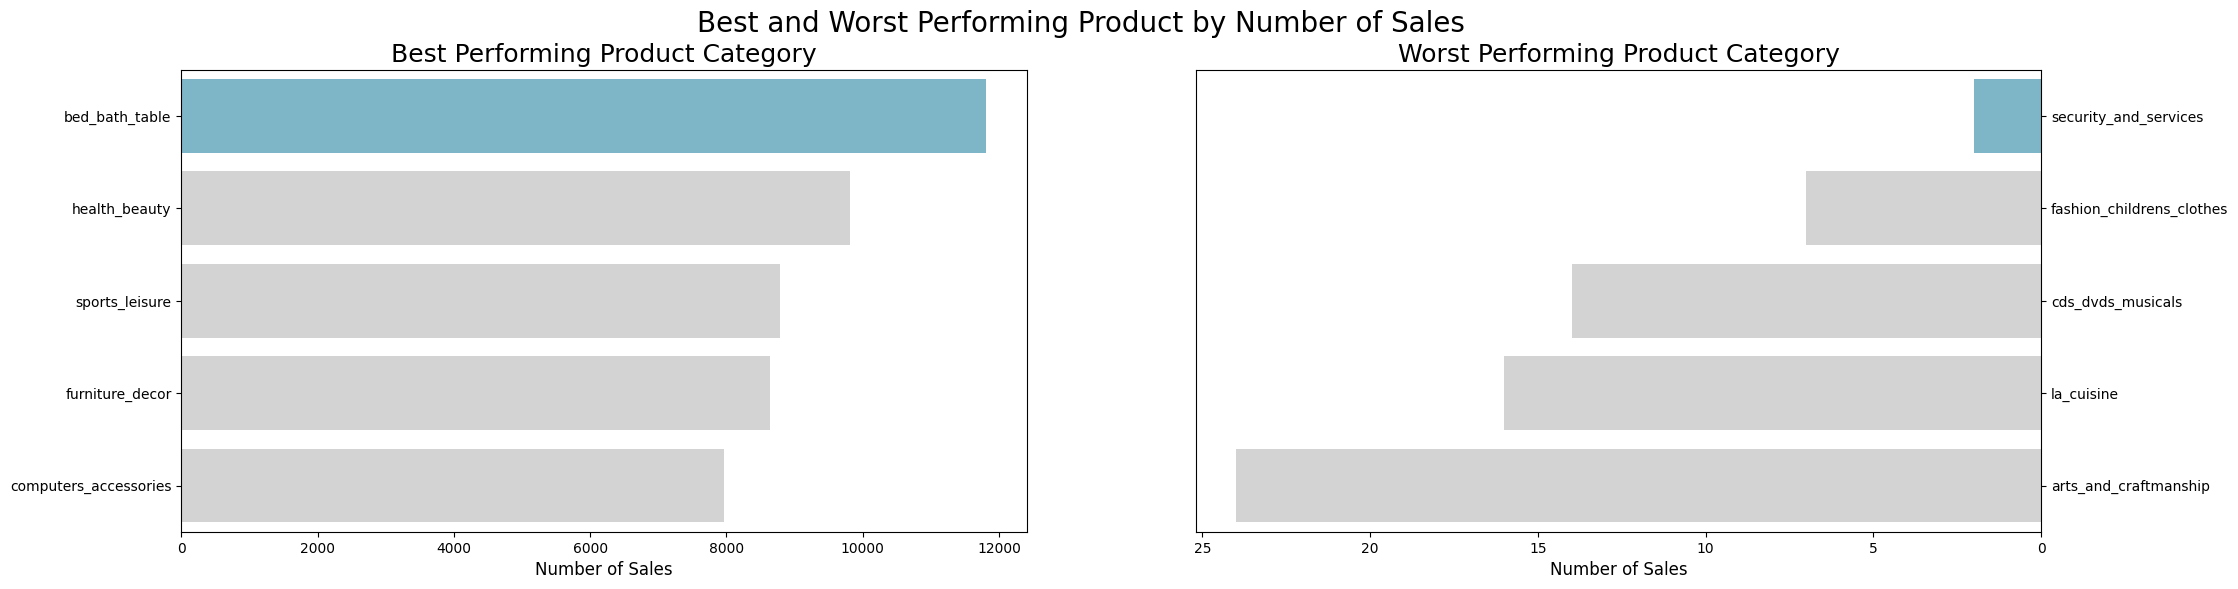

In [135]:
# Menghitung jumlah penjualan per kategori produk
sum_order_items_df = all_df_clean.groupby("product_category_name_english").order_item_id.count().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Best Performing
sns.barplot(
    x="order_item_id",
    y="product_category_name_english",
    data=sum_order_items_df.head(5),
    palette=colors,
    hue="product_category_name_english",
    legend=False,
    ax=ax[0]
)
ax[0].set_title("Best Performing Product Category", loc="center", fontsize=18)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Number of Sales", fontsize=12)

# Worst Performing
sns.barplot(
    x="order_item_id",
    y="product_category_name_english",
    data=sum_order_items_df.sort_values(by="order_item_id", ascending=True).head(5),
    palette=colors,
    hue="product_category_name_english",
    legend=False,
    ax=ax[1]
)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product Category", loc="center", fontsize=18)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Number of Sales", fontsize=12)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=20)
plt.show()

**Insight:**


*   Kategori `bed_bath_table` menjadi produk yang paling banyak terjual, menunjukkan dominasi pasar pada sektor tersebut.
*   Sebaliknya, kategori `security_and_service` memiliki angka penjualan yang sangat rendah. Hal ini bisa menjadi masukan bagi tim marketing untuk mengevaluasi apakah stok produk tersebut perlu dikurangi atau diperlukan strategi promosi baru untuk kategori tersebut.

**Mayoritas Customer Itu Dari Negara Bagian Mana?**

/tmp/ipykernel_200/998335743.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


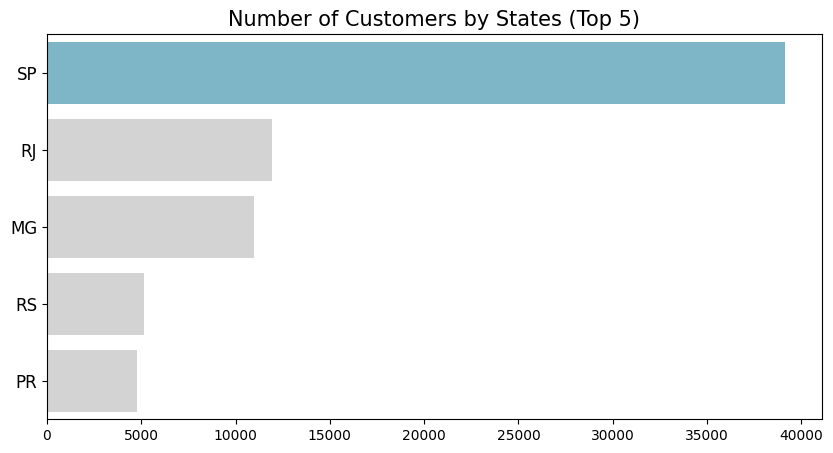

In [136]:
# Menyiapkan data untuk geospatial
bystate_df = all_df_clean.groupby(by="customer_state").customer_unique_id.nunique().reset_index()
bystate_df.rename(columns={
    "customer_unique_id": "customer_count"
}, inplace=True)

# Mengambil top 5 state
top_5_states = bystate_df.sort_values(by="customer_count", ascending=False).head(5)

# Visualisasi
plt.figure(figsize=(10, 5))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=top_5_states,
    palette=colors
)

plt.title("Number of Customers by States (Top 5)", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()

**Insight:**



*   Secara geografis, pelanggan terkonsentrasi sangat padat di wilayah Tenggara Brasil, dengan negara bagian `SP (São Paulo)` sebagai kontributor pelanggan terbesar, diikuti oleh `RJ (Rio de Janeiro)` dan `MG (Minas Gerais)`.
*   Dominasi wilayah SP sangat jauh melampaui wilayah lainnya, yang menunjukkan bahwa pusat aktivitas ekonomi dan target pasar utama perusahaan saat ini berada di area tersebut.
*   Data ini dapat digunakan untuk mengoptimalkan penempatan gudang `(hub logistik)` agar dapat memangkas biaya pengiriman dan mempercepat waktu pengiriman bagi mayoritas basis pelanggan.






**RFM Analysis**

In [137]:
# RFM DataFrame (pakai customer_unique_id)
rfm_df = all_df_clean.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",  # tanggal order terakhir
    "order_id": "nunique",              # Frequency
    "total_revenue": "sum"              # Monetary
})

# Rename kolom dengan nama yang konsisten
rfm_df.columns = ["customer_unique_id", "max_order_timestamp", "frequency", "monetary"]

# Hitung Recency (hari dari tanggal terakhir)
recent_date = all_df_clean["order_purchase_timestamp"].max().date()  # .date() biar hari penuh
rfm_df["recency"] = rfm_df["max_order_timestamp"].dt.date.apply(lambda x: (recent_date - x).days)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

print("RFM_df head:")
print(rfm_df.head())

print("\nRFM_df describe:")
print(rfm_df.describe())

RFM_df head:
                 customer_unique_id  frequency  monetary  recency
0  0000366f3b9a7992bf8c76cfdf3221e2          1    141.90      111
1  0000b849f77a49e4a4ce2b2a4ca5be3f          1     27.19      114
2  0000f46a3911fa3c0805444483337064          1     86.22      537
3  0000f6ccb0745a6a4b88665a16c9f078          1     43.62      321
4  0004aac84e0df4da2b147fca70cf8255          1    196.89      288

RFM_df describe:
          frequency      monetary       recency
count  93335.000000  93335.000000  93335.000000
mean       1.033396    173.399085    237.446799
std        0.209051    259.360203    152.568662
min        1.000000     10.070000      0.000000
25%        1.000000     64.000000    114.000000
50%        1.000000    110.600000    218.000000
75%        1.000000    188.400000    346.000000
max       15.000000  13664.080000    695.000000


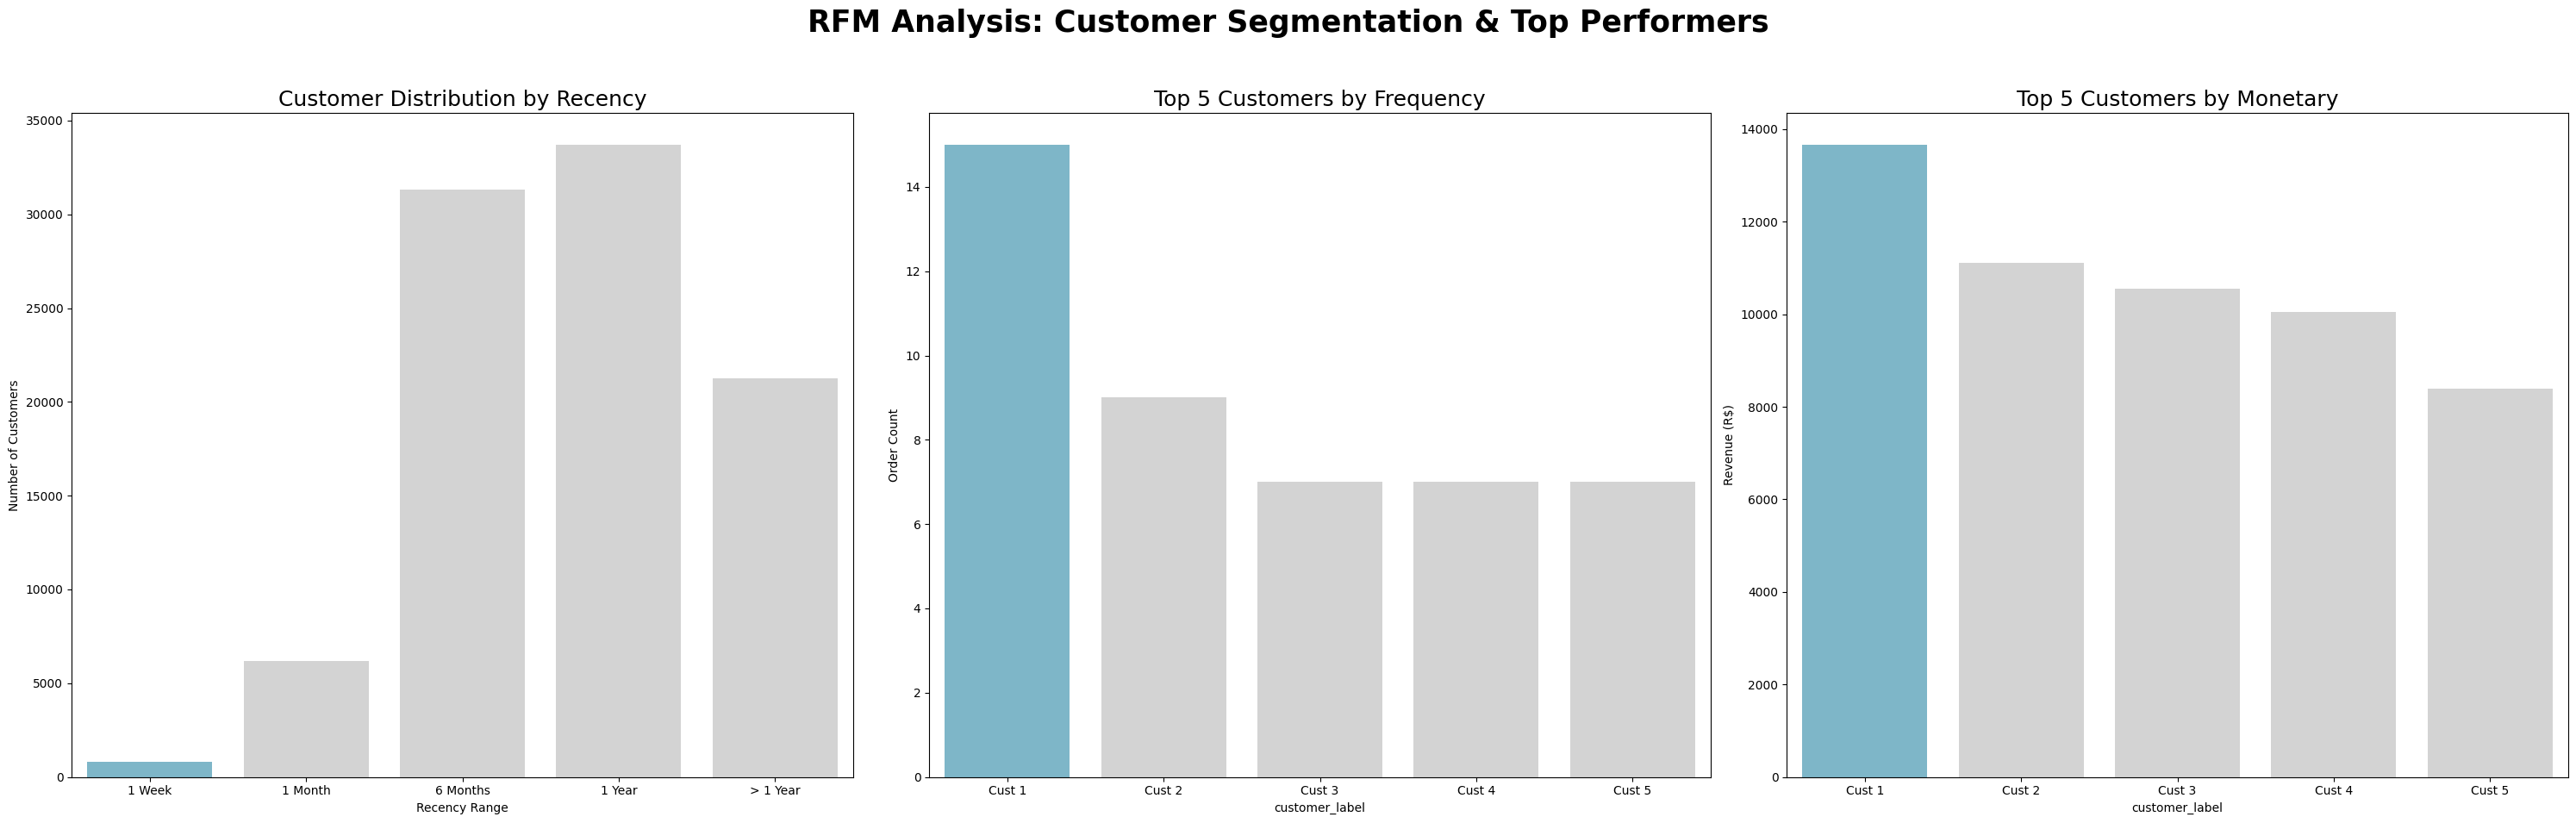

--- DETAIL DATA ---

[*] Customer Distribution by Recency:
recency_range  customer_id
       1 Week          802
      1 Month         6200
     6 Months        31344
       1 Year        33711
     > 1 Year        21278

[*] Top 5 Customers by Frequency:
                     customer_id  frequency  recency  monetary
8d50f5eadf50201ccdcedfb9e2ac8455         15        8    879.27
3e43e6105506432c953e165fb2acf44c          9      182   1172.67
ca77025e7201e3b30c44b472ff346268          7       89   1122.72
6469f99c1f9dfae7733b25662e7f1782          7       62    758.83
1b6c7548a2a1f9037c1fd3ddfed95f33          7      196   1021.12

[*] Top 5 Customers by Monetary:
                     customer_id  monetary  frequency  recency
0a0a92112bd4c708ca5fde585afaa872  13664.08          1      333
c4b224d2c784bae11ae98b6ae9f2454c  11111.40          1      457
85963fd37bfd387aa6d915d8a1065486  10553.28          1      195
be74c431147c32ab2d7c7cef5e4a995f  10055.22          1      110
edf81e1f3070b9dac

In [138]:
# Persiapan Data RFM
rfm_df = all_df_clean.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "total_revenue": "sum"
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

recent_date = all_df_clean["order_purchase_timestamp"].max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

# Custom Recency Segments
def recency_segment(days):
    if days <= 7: return '1 Week'
    elif days <= 30: return '1 Month'
    elif days <= 180: return '6 Months'
    elif days <= 360: return '1 Year'
    else: return '> 1 Year'

rfm_df['recency_range'] = rfm_df['recency'].apply(recency_segment)
recency_dist = rfm_df.groupby('recency_range', observed=True).customer_id.nunique().reset_index()

# SINKRONISASI: Urutan kategori harus sama dengan return value fungsi di atas
order_range = ["1 Week", "1 Month", "6 Months", "1 Year", "> 1 Year"]
recency_dist['recency_range'] = pd.Categorical(recency_dist['recency_range'], categories=order_range, ordered=True)

# Persiapan Top 5
labels = ["Cust 1", "Cust 2", "Cust 3", "Cust 4", "Cust 5"]
top_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5).copy()
top_frequency['customer_label'] = labels
top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5).copy()
top_monetary['customer_label'] = labels

# Visualisasi Gabungan
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# A. Distribusi Recency
sns.barplot(y="customer_id", x="recency_range", data=recency_dist.sort_values('recency_range'),
            palette=colors, hue="recency_range", legend=False, ax=ax[0])
ax[0].set_title("Customer Distribution by Recency", loc="center", fontsize=18)
ax[0].set_ylabel("Number of Customers")
ax[0].set_xlabel("Recency Range")

# B. Top 5 Frequency
sns.barplot(y="frequency", x="customer_label", data=top_frequency,
            palette=colors, hue="customer_label", legend=False, ax=ax[1])
ax[1].set_title("Top 5 Customers by Frequency", loc="center", fontsize=18)
ax[1].set_ylabel("Order Count")

# C. Top 5 Monetary
sns.barplot(y="monetary", x="customer_label", data=top_monetary,
            palette=colors, hue="customer_label", legend=False, ax=ax[2])
ax[2].set_title("Top 5 Customers by Monetary", loc="center", fontsize=18)
ax[2].set_ylabel("Revenue (R$)")

plt.suptitle("RFM Analysis: Customer Segmentation & Top Performers", fontsize=25, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Detail untuk Insight
print("--- DETAIL DATA ---")
print("\n[*] Customer Distribution by Recency:")
print(recency_dist.sort_values('recency_range').to_string(index=False))

print("\n[*] Top 5 Customers by Frequency:")
print(top_frequency[['customer_id', 'frequency', 'recency', 'monetary']].to_string(index=False))

print("\n[*] Top 5 Customers by Monetary:")
print(top_monetary[['customer_id', 'monetary', 'frequency', 'recency']].to_string(index=False))

**Insight Analisis RFM**

**Berdasarkan hasil parameter Recency, Frequency, dan Monetary, berikut adalah temuan kuncinya:**

1. **Tantangan Retensi (Recency)
Data: Hanya ada `802 pelanggan` yang bertransaksi dalam 1 minggu terakhir, sementara lebih dari `21.000 pelanggan` sudah tidak bertransaksi selama lebih dari setahun.**

Mayoritas pelanggan adalah churned customers atau pelanggan yang tidak kembali lagi. Dominasi pelanggan berada di rentang 6 bulan hingga 1 tahun. Ini menandakan platform sangat bergantung pada akuisisi pelanggan baru daripada menjaga loyalitas pelanggan lama.


---


2. **Karakteristik "One-Time Buyer" (Frequency)
Data: Pelanggan paling loyal (8d50f5...) melakukan `15 kali transaksi`. Namun, peringkat ke-3 hingga ke-5 hanya melakukan `7 kali transaksi`.**

Gap loyalitas antara pelanggan peringkat pertama dan lainnya cukup jauh. Secara keseluruhan, frekuensi belanja pelanggan masih tergolong rendah, yang menunjukkan bahwa sebagian besar pengguna hanya berbelanja saat membutuhkan barang spesifik, bukan sebagai platform belanja rutin.


---



3. **Fenomena "Big Spenders" vs Loyalitas (Monetary)
Data: Pelanggan dengan pengeluaran tertinggi (0a0a92...) menghabiskan R$ 13.664, namun ia hanya berbelanja 1 kali (Frequency = 1) dan terakhir kali aktif 333 hari yang lalu.**

Revenue terbesar perusahaan justru datang dari pelanggan tipe Single-Purchase High Value. Mereka membeli barang mewah atau mahal dalam satu kali transaksi besar, namun setelah itu tidak aktif kembali. Strategi "Customer Relationship Management" (CRM) sangat dibutuhkan untuk mengubah mereka menjadi pelanggan tetap.



**Rekomendasi Strategis untuk Bisnis**


*   **Re-activation Campaign**: Kirimkan promo khusus atau email reminders untuk 21.278 pelanggan di segmen "> 1 Year" agar mereka kembali bertransaksi.

*   **Loyalty Program:** Buat program poin atau cashback bertingkat untuk mendorong pelanggan yang sudah belanja 1-2 kali (seperti para Big Spenders) agar mau melakukan transaksi berikutnya.

*   **Fokus Segmentasi:** Berikan perlakuan VIP kepada pelanggan seperti ID 8d50f5... karena mereka adalah aset paling berharga yang menjaga roda transaksi tetap berputar secara konsisten.